Deep Bucket Lab

Learning Hydrologic Process Representations with an ODE-Based Bucket Model

This notebook is a focused, step-by-step exploration of hydrologic process modeling using a simple but physically interpretable leaky bucket system.

Rather than relying on stochastic simulations or black-box emulation, we formulate the bucket dynamics as a deterministic ordinary differential equation (ODE). This allows us to:
	•	separate the numerical solver timestep from the diagnostic output timestep,
	•	generate clean, reproducible simulations,
	•	and treat bucket properties as static parameters to be learned.

We deliberately remove routing convolutions and randomness to keep the system transparent and educational. The emphasis is on understanding how process representations, parameter choices, and numerical formulations shape hydrologic behavior—and how those parameters can be inferred from time series data.

This notebook is meant to be worked through slowly and deliberately. We will modify the model one cell at a time, building intuition for both the physics and the mathematics as we go.

Importing Numerical and Differentiable Computing Libraries

In this notebook, we move away from neural networks and instead focus on differentiable, physics-based simulation. We will use modern automatic differentiation and numerical tools to:
	•	define the bucket dynamics as an ODE,
	•	solve the system deterministically,
	•	and compute gradients with respect to static bucket parameters for learning and inference.

Machine learning, where it appears, is used in service of parameter estimation rather than black-box emulation.

In [1]:
# =========================
# Import libraries
# =========================
import jax
import jax.numpy as jnp
import diffrax as dfx
import matplotlib.pyplot as plt

Defining the Physical Bucket Model System

We model a single “bucket” as a deterministic ODE for water storage height h(t). Fluxes (ET, infiltration, spigot outflow, overflow) are defined as functions of h, time, and a set of static bucket parameters \theta.

Constants and time:
	•	g: gravitational acceleration.
	•	The ODE solver is timestep independent; we choose a separate diagnostic output interval only for sampling results.

In [2]:
# =========================
# Conventions & Shapes
# =========================

# ---- setup basic configurations ----
num_records = 1000
n_buckets = 30
dt_out = 1

# ---- reproducibility ----
key = jax.random.PRNGKey(0)

# ---- time + shapes ----
B = int(n_buckets)       # number of buckets
T = int(num_records)     # number of diagnostic samples

# TIME-MAJOR convention everywhere:
#   any time series X has shape (T, B)
#   bucket parameters p[k] have shape (B,)
#   broadcast parameters to time-major with pTB = p[None, :]  -> shape (1, B)

dt = float(dt_out)       # hours per diagnostic sample
t0 = 0.0
t1 = (T - 1) * dt
t_eval = jnp.arange(T, dtype=jnp.float32) * dt  # (T,)

# ---- constants / units ----
# We use time in HOURS. If you want Bernoulli outflow v = sqrt(2 g h),
# then g must be in m/hour^2.
g = 9.81 * (3600.0 ** 2)   # m / hour^2


### Precipitation generator parameters

We generate a stochastic precipitation forcing with three regimes: dry, light rain, and heavy rain.  
At each time step we first decide whether it rains (a per-bucket dry probability). If it rains, we choose between light and heavy rain using per-bucket regime probabilities.

Rainfall depths are sampled from two distributions:

- **Light rain** uses a *right-tailed Gumbel* distribution with parameters `(loc, scale)`, then is clipped to the interval `[0, light_heavy_threshold]`.
- **Heavy rain** uses a *Generalized Pareto* distribution with parameters `(shape, loc, scale)`, then is clipped to the interval `[light_heavy_threshold, max_precip]`.

All precipitation values are in units of **m/hour**.

Light precipitation values are generated using a Gumbel right distribution. Heavy precipitation values are generated using a generalized Pareto distribution.
<p align="center">
  <img src="figs/download-4.png" alt="Light precipitation" width="375"/>
  <img src="figs/download-5.png" alt="Heavy precipitation" width="375"/>
</p>

In [3]:
regime_prob_ranges = {
    "dry":   (0.4, 0.8),
    "light": (0.3, 0.6),
    "heavy": (0.1, 0.3),
}

light_heavy_threshold = 0.01
max_precip = 0.25

light_loc = 0.0008108
light_scale = 0.0009759

heavy_shape = 0.2341
heavy_loc = 0.0101
heavy_scale = 0.009250

Bucket Physical Attributes

To model the dynamics of the leaky bucket system, we define a set of physical attributes that control how each bucket stores water and releases it through different fluxes. These parameters determine the bucket’s response to a prescribed precipitation forcing and are treated as static properties of the system.

The bucket attributes fall into two categories:

Primary physical parameters (used directly in the ODE):  
	•	A_bucket: Cross-sectional area of the bucket [$m^2$], controlling storage capacity.  
	•	H_bucket: Bucket height [$m$], defining the maximum allowable water level.  
	•	A_spigot: Cross-sectional area of the spigot [$m^2$], controlling outflow magnitude.  
	•	H_spigot: Height of the spigot opening [$m$], defining the activation threshold for spigot flow.  
	•	K_infiltration: Soil permeability parameter, sampled in \log_{10} space and converted for use in the infiltration flux.  
	•	ET_parameter: Evapotranspiration rate parameter [$m/day$], controlling atmospheric water loss.  
	•	soil_depth: Soil depth [$m$], influencing infiltration behavior.

Sampling parameters (used only to generate physical parameters):
	•	rA_spigot: Dimensionless ratio used to derive A_spigot from bucket geometry.
	•	rH_spigot: Dimensionless ratio used to derive H_spigot from H_bucket.

To explore a wide range of hydrologic behaviors, we generate many buckets by randomly sampling these attributes from predefined ranges and distributions. This variability exists only at the level of bucket generation; once a bucket is defined, its dynamics are fully deterministic.

The following code cell specifies the parameter ranges and distributions used to generate this ensemble of bucket systems.

In [4]:
A_bucket_min = 5e2
A_bucket_max = 2e3

H_bucket_min = 0.5
H_bucket_max = 1.5

rA_spigot_min = 0.01
rA_spigot_max = 0.03

rH_spigot_min = 0.01
rH_spigot_max = 0.05

K_log10_mean = -13.8857
K_log10_std  = 1.1835

ET_shape = 2.2447
ET_loc   = 9.9807e-5
ET_scale = 0.0016

soil_depth_min = 0.3
soil_depth_max = 0.8

In [5]:
bucket_parameter_names = (
    "H_bucket",
    "A_spigot",
    "H_spigot",
    "K_infiltration",
    "ET_parameter",
    "soil_depth",
)

**Illustration of the Leaking Bucket Hydrological System**

Below is a schematic representation of the leaking bucket system used in our simulations. This diagram provides a visual understanding of the various components and dynamics of the system, including the bucket's structure, the spigot, and the flow of water.

<img src="figs/bucket_schematic.png" alt="Leaking Bucket System Schematic" width="250"/>


*Figure: Schematic of the Leaking Bucket Hydrological System. The diagram illustrates the key elements of the system, such as the bucket area, spigot, water inflow (precipitation), and outflows (spigot flow and overflow). Understanding this setup is crucial for comprehending how the system responds to different hydrological inputs and conditions.*

### 1.4 Creating a Sample of Diverse Buckets

With the parameters for our bucket and time splits established, our next step is to generate a diverse sample of buckets for our simulations. This diversity is key to creating a robust model that can generalize well across various hydrological scenarios.

We achieve this by randomly sampling from the possible ranges for each bucket attribute that we defined earlier. This process involves creating buckets with varying physical characteristics such as area, height, spigot size, and infiltration rates. By doing so, we ensure that our model encounters and learns from a wide array of system behaviors and responses.

The following code block will generate this sample of buckets, each with its unique set of boundary and initial conditions. This step builds a comprehensive dataset that reflects the variability and complexity of real-world hydrological systems, thereby enhancing the learning and predictive capabilities of our LSTM model.


In [6]:
# =========================
# Bucket parameter sampling (explicit specs) + setup_buckets
# =========================

A_BUCKET_MIN, A_BUCKET_MAX = 5e2, 2e3
H_BUCKET_MIN, H_BUCKET_MAX = 0.5, 1.5
RA_SPIGOT_MIN, RA_SPIGOT_MAX = 0.01, 0.03
RH_SPIGOT_MIN, RH_SPIGOT_MAX = 0.01, 0.05
SOIL_DEPTH_MIN, SOIL_DEPTH_MAX = 0.3, 0.8

LOG10K_MU, LOG10K_SIGMA = -13.8857, 1.1835
ET_SHAPE, ET_LOC, ET_SCALE = 2.2447, 9.9807e-5, 0.0016

def setup_buckets(key, B):
    """
    Sample an ensemble of B “leaky bucket” systems for deterministic ODE simulation.

    Each bucket is defined by fixed (time-invariant) physical parameters and an initial
    storage height h0. Parameters are sampled independently across buckets:
      - A_bucket ~ Uniform[A_BUCKET_MIN, A_BUCKET_MAX]                      [m^2]
      - H_bucket ~ Uniform[H_BUCKET_MIN, H_BUCKET_MAX]                      [m]
      - rA_spigot ~ Uniform[RA_SPIGOT_MIN, RA_SPIGOT_MAX]                   [-]
      - rH_spigot ~ Uniform[RH_SPIGOT_MIN, RH_SPIGOT_MAX]                   [-]
      - soil_depth ~ Uniform[SOIL_DEPTH_MIN, SOIL_DEPTH_MAX]                [m]
      - log10(K) ~ Normal(LOG10K_MU, LOG10K_SIGMA)                           [-]
      - ET_parameter ~ Weibull-min(shape=ET_SHAPE, loc=ET_LOC, scale=ET_SCALE) [m/day]

    Derived parameters used directly in the ODE:
      - A_spigot = pi * (0.5 * H_bucket * rA_spigot)^2                      [m^2]
      - H_spigot = H_bucket * rH_spigot                                     [m]
      - h0 ~ Uniform[0, H_bucket]                                           [m]

    Returns
    -------
    p : dict[str, jnp.ndarray]
        Parameter pytree with arrays shaped (B,), containing only ODE-relevant fields:
        A_bucket, H_bucket, A_spigot, H_spigot, soil_depth, K_infiltration (log10),
        ET_parameter.
    h0 : jnp.ndarray
        Initial storage heights, shape (B,).
    key : jax.random.PRNGKey
        Updated RNG key.
    """
    key, kA, kH, krA, krH, kL, kK, kET, kh0 = jax.random.split(key, 9)

    A_bucket = jax.random.uniform(kA, (B,), minval=A_BUCKET_MIN, maxval=A_BUCKET_MAX)
    H_bucket = jax.random.uniform(kH, (B,), minval=H_BUCKET_MIN, maxval=H_BUCKET_MAX)
    rA_spigot = jax.random.uniform(krA, (B,), minval=RA_SPIGOT_MIN, maxval=RA_SPIGOT_MAX)
    rH_spigot = jax.random.uniform(krH, (B,), minval=RH_SPIGOT_MIN, maxval=RH_SPIGOT_MAX)
    soil_depth = jax.random.uniform(kL, (B,), minval=SOIL_DEPTH_MIN, maxval=SOIL_DEPTH_MAX)

    K_infiltration = LOG10K_MU + LOG10K_SIGMA * jax.random.normal(kK, (B,))

    u = jax.random.uniform(kET, (B,), minval=1e-6, maxval=1.0 - 1e-6)
    w = (-jnp.log1p(-u)) ** (1.0 / ET_SHAPE)
    ET_parameter = ET_LOC + ET_SCALE * w

    A_spigot = jnp.pi * (0.5 * H_bucket * rA_spigot) ** 2
    H_spigot = H_bucket * rH_spigot
    h0 = jax.random.uniform(kh0, (B,), minval=0.0, maxval=1.0) * H_bucket

    p = dict(
        A_bucket=A_bucket,
        H_bucket=H_bucket,
        A_spigot=A_spigot,
        H_spigot=H_spigot,
        soil_depth=soil_depth,
        K_infiltration=K_infiltration,
        ET_parameter=ET_parameter,
    )
    return p, h0, key

Running setup_buckets initializes an ensemble of bucket systems by stochastically sampling their physical attributes and initial water levels from predefined ranges. Each bucket represents a distinct, fixed set of parameters that will be used in deterministic ODE simulations driven by prescribed precipitation forcings. The resulting collection of buckets allows us to explore how differences in physical properties influence system behavior and to support parameter estimation and sensitivity experiments across a diverse set of hydrologic configurations.

In [7]:
# =========================
# Do the bucket setup
# =========================
key = jax.random.PRNGKey(0)
buckets, h0, key = setup_buckets(key, n_buckets)

Creating the Synthetic Precipitation Forcing

Synthetic precipitation is the external forcing that drives each bucket model. We generate a precipitation time series for each bucket using a stochastic rainfall process (to mimic variability across scenarios). Once generated, each precipitation realization is treated as fixed input data, and the bucket dynamics evolve deterministically under the ODE solver.

This step has two parts:
	1.	Assign rainfall regime parameters (None / Light / Heavy) for each bucket by sampling from the specified probability ranges.  
	2.	Generate a precipitation time series from those regime parameters and depth distributions, producing a unique forcing record for each bucket.

In [8]:
# =========================
# Rain regime parameter sampling
# =========================

p_none_min,  p_none_max  = 0.4, 0.8
p_light_min, p_light_max = 0.3, 0.6
p_heavy_min, p_heavy_max = 0.1, 0.3

light_loc, light_scale = 0.0008108, 0.0009759
heavy_shape, heavy_loc, heavy_scale = 0.2341, 0.0101, 0.009250

threshold_precip = 0.01
max_precip = 0.25


def sample_rain_params(key, B):
    """
    Assign each bucket its own rain-regime probabilities.

    This notebook uses a simple 3-regime rainfall generator:
      - None: dry timestep (no rain)
      - Light: rain depth drawn from a right-skewed light-rain distribution
      - Heavy: rain depth drawn from a heavy-tail distribution

    Here we only sample the per-bucket regime probabilities (p_none, p_light, p_heavy).
    The depth-distribution parameters (light_loc/scale, heavy_shape/loc/scale) are
    shared across all buckets and are defined as global scalars above.
    """
    key, k0, k1, k2 = jax.random.split(key, 4)
    p_none  = jax.random.uniform(k0, (B,), minval=p_none_min,  maxval=p_none_max)
    p_light = jax.random.uniform(k1, (B,), minval=p_light_min, maxval=p_light_max)
    p_heavy = jax.random.uniform(k2, (B,), minval=p_heavy_min, maxval=p_heavy_max)
    return {"p_none": p_none, "p_light": p_light, "p_heavy": p_heavy}, key

Generate Random Rain Forcing

Next we generate stochastic precipitation time series to serve as the external forcing for each bucket. The rainfall generator uses the regime probabilities (none / light / heavy) assigned per bucket and samples event depths from the specified ranges. We can optionally include simple temporal dependence (e.g., persistence from the previous timestep) to create more realistic storm sequences.

Importantly, this randomness exists only in the forcing generation step. Once a precipitation series is generated, it is treated as fixed input data, and the bucket dynamics evolve deterministically under the ODE solver.


In [9]:
# =========================
# Generate precipitation (time-major)
# =========================

def generate_precip(
    key,
    rain_params,
    T,
    threshold_precip,
    max_precip,
    light_loc,
    light_scale,
    heavy_shape,
    heavy_loc,
    heavy_scale,
):
    """
    Generate precipitation P(t, b) with shape (T, B) in m/hour.

    At each timestep and for each bucket, precipitation is generated by:
      1) A Bernoulli "rains vs. none" draw controlled by p_none(b).
      2) Conditional on raining, selecting Light vs. Heavy using a one-step
         persistence heuristic based on whether the previous precipitation
         was below threshold_precip.

    Light intensities are sampled from a right-skewed Gumbel distribution and
    clipped to [0, threshold_precip]. Heavy intensities are sampled from a
    generalized Pareto distribution and clipped to [threshold_precip, max_precip].

    Parameters
    ----------
    key : jax.random.PRNGKey
        Random key.
    rain_params : dict
        Contains per-bucket regime controls:
          p_none, p_light, p_heavy with shape (B,).
    T : int
        Number of timesteps.
    threshold_precip : float
        Boundary between light and heavy (m/hour).
    max_precip : float
        Maximum precipitation intensity (m/hour).
    light_loc, light_scale : float
        Gumbel parameters for light precipitation.
    heavy_shape, heavy_loc, heavy_scale : float
        Generalized Pareto parameters for heavy precipitation.

    Returns
    -------
    P_series : jnp.ndarray
        Precipitation with shape (T, B).
    key : jax.random.PRNGKey
        Updated key.
    """
    B = int(rain_params["p_none"].shape[0])

    def gumbel_right(k):
        u = jax.random.uniform(k, (B,), minval=1e-6, maxval=1.0 - 1e-6)
        return light_loc - light_scale * jnp.log(-jnp.log(u))

    def genpareto(k):
        u = jax.random.uniform(k, (B,), minval=1e-6, maxval=1.0 - 1e-6)
        x0 = heavy_loc - heavy_scale * jnp.log(u)
        x = heavy_loc + (heavy_scale / heavy_shape) * (u ** (-heavy_shape) - 1.0)
        return jnp.where(jnp.abs(heavy_shape) < 1e-8, x0, x)

    def step(carry, _):
        prev, key = carry
        key, k0, k1, k2 = jax.random.split(key, 4)

        rains = jax.random.uniform(k0, (B,)) >= rain_params["p_none"]

        was_lightish = prev < threshold_precip
        u = jax.random.uniform(k1, (B,))
        choose_light = jnp.where(
            was_lightish,
            u < rain_params["p_light"],
            ~(u < rain_params["p_heavy"]),
        )

        rL = jnp.clip(gumbel_right(k2), 0.0, threshold_precip)
        rH = jnp.clip(genpareto(k2), threshold_precip, max_precip)
        rain = jnp.where(rains, jnp.where(choose_light, rL, rH), 0.0)

        return (rain, key), rain

    init = (jnp.zeros((B,), dtype=jnp.float32), key)
    (_, key), P_series = jax.lax.scan(step, init, xs=None, length=int(T))
    return P_series, key

Now that we have a stochastic generator for rainfall events, the next step is to build a precipitation forcing time series for each bucket. These precipitation sequences are generated upstream and then treated as fixed inputs to the deterministic ODE solver.

For each bucket, we:  
	1.	sample a set of rainfall regime parameters using pick_rain_params, and  
	2.	iterate through time using random_rain to produce a precipitation sequence.

We store the resulting forcings in a dictionary (one time series per bucket) so they can be passed unchanged into later simulation and parameter-estimation steps. The next code cell generates and stores these precipitation time series for all buckets.

In [10]:
# =========================
# Run precipitation generation
# =========================
rain_params, key = sample_rain_params(key, n_buckets)

P_series, key = generate_precip(
    key=key,
    rain_params=rain_params,
    T=num_records,
    threshold_precip=threshold_precip,
    max_precip=max_precip,
    light_loc=light_loc,
    light_scale=light_scale,
    heavy_shape=heavy_shape,
    heavy_loc=heavy_loc,
    heavy_scale=heavy_scale,
)

Running Numerical Simulations to Generate “Ground Truth” Data

We now generate “ground truth” by solving the leaky bucket system as a deterministic ODE. For each bucket (fixed parameters) and its precipitation forcing time series, we solve for the storage state h(t) and compute diagnostic fluxes such as spigot outflow and overflow. Because we use an ODE solver, the dynamics are timestep independent; we choose a separate diagnostic output interval only for sampling results on a convenient time grid.

These simulated, noise-free trajectories represent the underlying “truth.”

Notes on the process representations
Infiltration (Darcy-style toy parameterization):
We use a simplified flux form based on Darcy’s law, with a hydraulic head difference \Delta h = h + L (water height plus soil depth). This yields an infiltration rate that increases with storage and depends on permeability and soil depth.

In [11]:
def positive_part(x, beta=50.0):
    """
    Smooth approximation to max(x, 0) using a numerically stable softplus.

    This is used to turn thresholded physical processes (e.g., spigot head, overflow
    exceedance) into differentiable functions. Smoothness helps both ODE solvers
    (fewer discontinuities) and gradient-based parameter inference.

    Parameters
    ----------
    x : array-like
        Input values.
    beta : float
        Sharpness of the transition near 0. Larger values approach hard max(x, 0).

    Returns
    -------
    array-like
        Values approximately equal to max(x, 0), with a smooth transition at 0.
    """
    bx = beta * x
    return jnp.where(bx > 20.0, x, jnp.log1p(jnp.exp(bx)) / beta)


def cap_to_bucket(h, H_bucket, beta=50.0):
    """
    Smoothly enforce physical storage bounds: 0 ≤ h ≤ H_bucket.

    This function does not modify the ODE state itself. Instead, it defines
    the *effective* storage seen by flux laws, ensuring that infiltration,
    spigot flow, and overflow respond only to physically admissible water
    levels.

    The lower bound (h ≥ 0) and upper bound (h ≤ H_bucket) are enforced using
    smooth positive-part operators, preserving differentiability for both
    numerical integration and gradient-based inference.

    Parameters
    ----------
    h : array-like
        Raw storage state.
    H_bucket : array-like
        Bucket rim height.
    beta : float
        Sharpness of the bounding transition.

    Returns
    -------
    array-like
        Storage smoothly constrained to [0, H_bucket].
    """
    h_pos = positive_part(h, beta)
    return H_bucket - positive_part(H_bucket - h_pos, beta)

def cap_storage(h, h_max, beta=50.0):
    """
    Smoothly enforce physical storage bounds: 0 <= h <= h_max.

    This is a *diagnostic/flux-evaluation* clamp (not a hard state projection).
    It keeps flux formulas well-behaved when the ODE state briefly wanders
    negative or above the rim due to numerical error, while preserving
    differentiability.

    Parameters
    ----------
    h : array-like
        Storage height (m). Can be scalar, (B,), (T,B), etc.
    h_max : array-like
        Bucket rim height (m). Typically shape (B,) and broadcasts over time.
    beta : float
        Smoothness of the positive-part operator.

    Returns
    -------
    array-like
        Bounded storage height in [0, h_max], with smooth transitions.
    """
    h0 = positive_part(h, beta=beta)
    return h_max - positive_part(h_max - h0, beta=beta)

In [12]:
def et_rate(t, p):
    """
    Deterministic diurnal evapotranspiration rate (m/hour).

    Evapotranspiration follows a positive half-wave of a 24-hour sine cycle.
    The amplitude is scaled so that the integral over any full day equals
    the bucket-specific evapotranspiration parameter ET_parameter (m/day).

    Parameters
    ----------
    t : float or array-like
        Time in hours. May be scalar or a time array.
    p : dict
        Bucket parameter dictionary containing:
          - p["ET_parameter"]: evapotranspiration parameter (m/day), shape (B,)

    Returns
    -------
    array-like
        Evapotranspiration rate in m/hour, broadcast over buckets and time.
    """
    diurnal = jnp.maximum(jnp.sin((jnp.pi / 12.0) * t), 0.0)
    return p["ET_parameter"] * (jnp.pi / 24.0) * diurnal


def infiltration_rate(h, p, c_inf=0.05):
    """
    Darcy-style infiltration rate (m/hour).

    This is a toy parameterization based on a hydraulic-gradient proxy (h + L)/L,
    scaled by a bucket-specific permeability-like parameter.

    Parameters
    ----------
    h : array-like
        Water storage height [m]. Can be scalar, (B,), or (T,B) depending on context.
    p : dict
        Parameter dict containing:
          - p["K_infiltration"] : (B,) log10(K) values
          - p["soil_depth"]     : (B,) soil depth [m]
    c_inf : float
        Dimensionless scaling constant for the infiltration rate.

    Returns
    -------
    array-like
        Infiltration rate [m/hour], broadcast-compatible with `h`.
    """
    K = 10.0 ** p["K_infiltration"]
    L = p["soil_depth"]
    return c_inf * positive_part(K * (h + L) / L)


def q_spigot_rate(h, p, drain_timescale_hr=1.0):
    """
    Spigot outflow rate (m/hour), expressed as an equivalent depth rate over the bucket area.

    We model spigot discharge with a Bernoulli velocity:
        v = sqrt(2 g head)

    where
        head = max(h - H_spigot, 0).

    The volumetric discharge is A_spigot * v, and dividing by A_bucket converts this
    to a depth-rate over the bucket surface:
        q_spigot = (A_spigot / A_bucket) * v.

    A purely Bernoulli spigot can drain unrealistically fast in stiff regimes or when
    the solver takes large steps. To keep the dynamics numerically stable and physically
    reasonable, we cap the discharge so it cannot remove more than the available head
    above the spigot over a characteristic drainage timescale:
        q_spigot <= head / drain_timescale_hr.

    Parameters
    ----------
    h : array-like
        Storage height (m).
    p : dict
        Bucket parameter dict with keys:
          - "A_spigot" (m^2)
          - "A_bucket" (m^2)
          - "H_spigot" (m)
          - "g" (m/hour^2)  (or supply g globally and omit this key)
    drain_timescale_hr : float
        Timescale (hours) limiting how fast the spigot can reduce head above the spigot.

    Returns
    -------
    array-like
        Spigot outflow rate in m/hour.
    """
    head = positive_part(h - p["H_spigot"])
    v = jnp.sqrt(2.0 * g * head)
    q_raw = (p["A_spigot"] / p["A_bucket"]) * v
    q_cap = head / drain_timescale_hr
    return jnp.minimum(q_raw, q_cap)


def q_overflow_rate(h, h_rim, spill_timescale_hr, beta=50.0):
    """
    Overflow spill rate (m/hour).

    Produces a smooth, proportional spill based on exceedance above the rim.
    The spill_timescale_hr controls how quickly excess water is shed.

    Parameters
    ----------
    h : array-like
        Storage height (m). In a direct-state implementation, use the *raw*
        state here if you want overflow to react to exceedance.
    h_rim : array-like
        Bucket rim height (m).
    spill_timescale_hr : float
        Timescale for removing exceedance (hours). Smaller => faster spill.
    beta : float
        Smoothness for positive-part.

    Returns
    -------
    array-like
        Overflow rate (m/hour).
    """
    excess = positive_part(h - h_rim, beta=beta)
    return excess / spill_timescale_hr

In [13]:
# =========================
# Bucket dynamics
# =========================
def bucket_rhs(t, h, args):
    """
    Bucket ODE with physically interpretable flux handling.

    State
    -----
    h : array (B,)
        Water storage height [m].

    Notes
    -----
    All process laws are evaluated on a bounded effective height
    h_cap = clip(h, 0, H_bucket) (implemented smoothly) to avoid unphysical
    fluxes if the numerical state wanders.

    Overflow is treated as an enforcement of the rim constraint, not as an
    independent drainage process. When the bucket is (approximately) full,
    any positive net-inflow tendency is diverted to overflow so that storage
    does not increase beyond the rim:

        dh_raw = P - ET - INF - QS
        QO     = max(dh_raw, 0) * gate(h_cap ≈ H_bucket)
        dhdt   = dh_raw - QO
    """
    p, precip_fn = args

    Hb = p["H_bucket"]
    h_cap = cap_to_bucket(h, Hb)

    P = precip_fn(t)
    ET = et_rate(t, p)
    INF = infiltration_rate(h_cap, p)
    QS = q_spigot_rate(h_cap, p)

    dh_raw = P - ET - INF - QS

    eps, k = 1e-3, 50.0
    gate = jax.nn.sigmoid(k * (h_cap / Hb - (1.0 - eps)))
    QO = positive_part(dh_raw) * gate

    return dh_raw - QO

Now that we can solve the bucket ODE for a single configuration, the next step is to run simulations for each bucket in our ensemble and store the results.

We store the outputs in a dictionary, bucket_sims, where each key is a bucket index and each value is a set of JAX arrays containing the simulated state and diagnostic fluxes sampled on t_eval. This organization makes it easy to compare behaviors across buckets, compute summary statistics, and later construct synthetic observations for parameter estimation.

The next code cell iterates over all buckets, calls solve_bucket for each one, and stores the resulting time series in bucket_sims.

In [14]:
def solve_all_buckets(P_series, solver=None):
    """
    Solve an ensemble of independent bucket ODEs in one batched Diffrax call.

    Inputs
    ------
    P_series : array (T, B)
        Piecewise-constant precipitation rate [m/hour] sampled on t_eval.
    solver : diffrax solver (optional)

    Returns
    -------
    sims : dict of arrays (T, B)
        Time-major diagnostics sampled on t_eval:
        precip, et, infiltration, q_spigot, q_overflow, h_bucket.

    Notes
    -----
    The integrated state is h(t) [m]. Fluxes are evaluated on a capped height
    h_cap in [0, H_bucket] for physical consistency. Overflow is computed in the
    same physically-interpretable way as bucket_rhs: it diverts only the
    positive surplus tendency when the bucket is (near) full.
    """
    solver = dfx.Tsit5() if solver is None else solver

    P_series = jnp.asarray(P_series)
    p = {k: buckets[k] for k in buckets.keys()}
    h_init = jnp.asarray(h0)

    def precip_fn(t):
        idx = jnp.clip(jnp.floor(t / dt).astype(jnp.int32), 0, T - 1)
        return P_series[idx, :]

    jax.eval_shape(lambda y: bucket_rhs(t_eval[0], y, (p, precip_fn)), h_init)
    sol = dfx.diffeqsolve(
        dfx.ODETerm(bucket_rhs),
        solver,
        t0=t_eval[0],
        t1=t_eval[-1],
        dt0=dt,
        y0=h_init,
        args=(p, precip_fn),
        saveat=dfx.SaveAt(ts=t_eval),
    )

    h = sol.ys

    eps = 1e-3
    k = 50.0

    def diag_at_t(ti, hi):
        Hb = p["H_bucket"]
        h_cap = cap_to_bucket(hi, Hb)

        P = precip_fn(ti)
        ET = et_rate(ti, p)
        INF = infiltration_rate(h_cap, p)
        QS = q_spigot_rate(h_cap, p)

        dh_raw = P - ET - INF - QS
        near_full = jax.nn.sigmoid(k * ((h_cap / Hb) - (1.0 - eps)))
        QO = positive_part(dh_raw) * near_full

        return P, ET, INF, QS, QO

    P_diag, ET_diag, INF_diag, QS_diag, QO_diag = jax.vmap(diag_at_t)(t_eval, h)

    return dict(
        precip=P_diag,
        et=ET_diag,
        infiltration=INF_diag,
        q_spigot=QS_diag,
        q_overflow=QO_diag,
        h_bucket=h,
    )

In [15]:
# =========================
# Run the solver
# =========================
all_sims = solve_all_buckets(P_series)

Visualizing a Sample of the Bucket Fluxes

After solving the bucket ODEs, we visually inspect a few simulated trajectories to confirm the system behaves sensibly. Plotting helps us sanity-check the forcing, the storage response h(t), and the key diagnostic fluxes—especially spigot outflow and overflow—under different bucket configurations.

The function viz_simulation plots, for a selected bucket:  
	•	Forcing and atmospheric loss: precipitation and evapotranspiration over time.  
	•	State and flux diagnostics: storage height h(t), spigot outflow, overflow, and infiltration.

This step is purely diagnostic: it helps verify that our ODE formulation, parameter ranges, and forcing generation produce reasonable dynamics before we move on to adding observation noise and performing parameter inference.

In [16]:
def viz_simulation(ibuc, start=300, n=300):
    """
    Print bucket parameters and plot forcing + diagnostic fluxes + storage
    for a selected bucket index. Uses batched JAX arrays stored in all_sims.
    """
    p = {k: float(buckets[k][ibuc]) for k in buckets.keys()}

    # --- Static bucket characteristics ---
    attrs = {
        "Bucket ID":               ibuc,
        "Bucket area (m²)":        p["A_bucket"],
        "Spigot area (m²)":        p["A_spigot"],
        "Bucket height (m)":       p["H_bucket"],
        "Spigot height (m)":       p["H_spigot"],
        "K_infiltration (log10)":  p["K_infiltration"],
        "ET parameter (m/day)":    p["ET_parameter"],
        "Soil depth (m)":          p["soil_depth"],
        "Overflow mean (m/h)":     float(jnp.mean(all_sims["q_overflow"][:, ibuc])),
        "Overflow max (m/h)":      float(jnp.max(all_sims["q_overflow"][:, ibuc])),
    }

    for name, val in attrs.items():
        print(f"{name:<25}: {val}" if name == "Bucket ID" else f"{name:<25}: {val:.4g}")

    # --- Pull this bucket’s time series (T,) ---
    P   = all_sims["precip"][:, ibuc]
    ET  = all_sims["et"][:, ibuc]
    INF = all_sims["infiltration"][:, ibuc]
    QS  = all_sims["q_spigot"][:, ibuc]
    QO  = all_sims["q_overflow"][:, ibuc]
    H   = all_sims["h_bucket"][:, ibuc]

    dt = float(dt_out)

    def cumtrapz(x):
        return jnp.concatenate([
            jnp.array([0.0]),
            jnp.cumsum(0.5 * (x[1:] + x[:-1]) * dt)
        ])

    cum_precip = cumtrapz(P)
    cum_et     = cumtrapz(ET)
    cum_inf    = cumtrapz(INF)
    cum_runoff = cumtrapz(QS + QO)

    storage0 = H[0]
    mass_out_tot = cum_et + cum_inf + cum_runoff + (H - storage0)
    residual_frac = (cum_precip - mass_out_tot) / jnp.maximum(cum_precip, 1e-12)

    print("\nMass-balance summary (final):")
    print(f"{'Total precip (m)':<25}: {float(cum_precip[-1]):.4g}")
    print(f"{'Total ET (m)':<25}: {float(cum_et[-1]):.4g}")
    print(f"{'Total infiltration (m)':<25}: {float(cum_inf[-1]):.4g}")
    print(f"{'Total runoff (m)':<25}: {float(cum_runoff[-1]):.4g}")
    print(f"{'Final storage (m)':<25}: {float(H[-1]):.4g}")
    print(f"{'Mass out + stored (m)':<25}: {float(mass_out_tot[-1]):.4g}")
    print(f"{'Residual fraction':<25}: {float(residual_frac[-1]):.2%}")

    # --- Plot window ---
    end = min(start + n, P.shape[0])
    tt = t_eval[start:end]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)

    axes[0].plot(tt, P[start:end],   label="precip")
    axes[0].plot(tt, ET[start:end],  label="et")
    axes[0].plot(tt, INF[start:end], label="infiltration")
    axes[0].set(title="Forcing / losses", xlabel="Time (h)", ylabel="m/h")
    axes[0].legend()

    # --- Outflows on two y-axes (standard matplotlib colors) ---
    ax = axes[1]
    ax2 = ax.twinx()

    l1, = ax.plot(
        tt, QO[start:end],
        color="C0",          # default blue
        label="q_overflow"
    )
    l2, = ax2.plot(
        tt, QS[start:end],
        color="C1",          # default orange
        label="q_spigot"
    )

    ax.set(
        title="Outflows",
        xlabel="Time (h)",
        ylabel="q_overflow (m/h)"
    )
    ax2.set(ylabel="q_spigot (m/h)")

    ax.legend([l1, l2], ["q_overflow", "q_spigot"], loc="best")

    # --- Storage ---
    axes[2].plot(tt, H[start:end], label="h_bucket")

    # bucket rim (H_bucket)
    axes[2].axhline(
        p["H_bucket"],
        linestyle="--",
        color="k",
        linewidth=1.0,
        label="bucket rim"
    )

    axes[2].set(title="Storage", xlabel="Time (h)", ylabel="m")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    plt.close()

Now, let's visualize the simulation results for the buckets in our validation set. This will help us assess the model's performance on different bucket configurations and ensure that the simulated fluxes are realistic and consistent with our expectations.

Bucket ID                : 0
Bucket area (m²)         : 510.9
Spigot area (m²)         : 0.0003635
Bucket height (m)        : 1.402
Spigot height (m)        : 0.02264
K_infiltration (log10)   : -12.51
ET parameter (m/day)     : 0.001415
Soil depth (m)           : 0.669
Overflow mean (m/h)      : 1.08e-17
Overflow max (m/h)       : 6.183e-15

Mass-balance summary (final):
Total precip (m)         : 6.668
Total ET (m)             : 0.05911
Total infiltration (m)   : 0.6925
Total runoff (m)         : 5.975
Final storage (m)        : 0.3137
Mass out + stored (m)    : 6.677
Residual fraction        : -0.13%


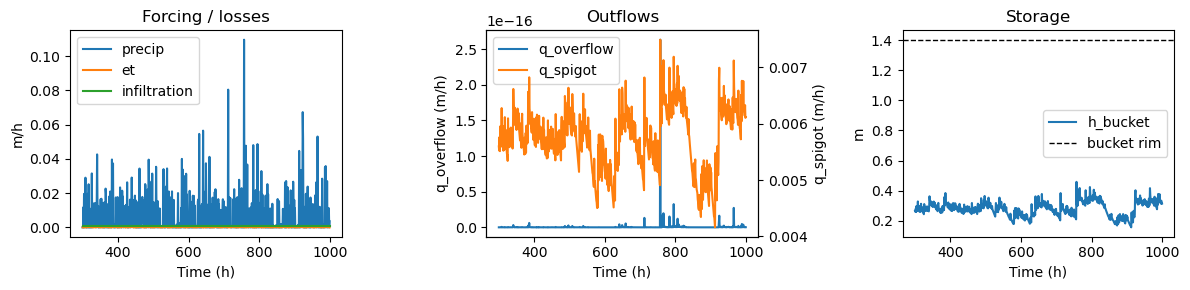

Bucket ID                : 1
Bucket area (m²)         : 531.3
Spigot area (m²)         : 0.0009541
Bucket height (m)        : 1.412
Spigot height (m)        : 0.05531
K_infiltration (log10)   : -15.03
ET parameter (m/day)     : 0.0006034
Soil depth (m)           : 0.6127
Overflow mean (m/h)      : 2.663e-21
Overflow max (m/h)       : 2.082e-18

Mass-balance summary (final):
Total precip (m)         : 4.72
Total ET (m)             : 0.0252
Total infiltration (m)   : 0.6925
Total runoff (m)         : 4.058
Final storage (m)        : 0.03256
Mass out + stored (m)    : 4.719
Residual fraction        : 0.03%


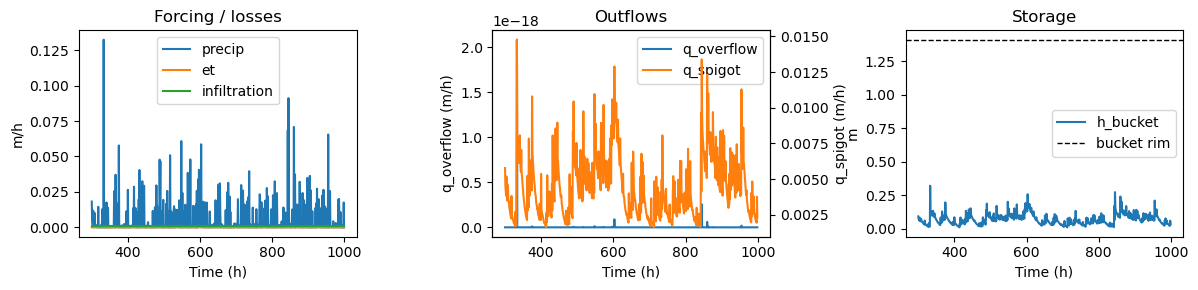

Bucket ID                : 2
Bucket area (m²)         : 1372
Spigot area (m²)         : 0.0004696
Bucket height (m)        : 0.841
Spigot height (m)        : 0.0117
K_infiltration (log10)   : -13.58
ET parameter (m/day)     : 0.0008904
Soil depth (m)           : 0.7489
Overflow mean (m/h)      : 0.002544
Overflow max (m/h)       : 0.0607

Mass-balance summary (final):
Total precip (m)         : 6.593
Total ET (m)             : 0.03718
Total infiltration (m)   : 0.6925
Total runoff (m)         : 7.289
Final storage (m)        : 0.79
Mass out + stored (m)    : 8.187
Residual fraction        : -24.18%


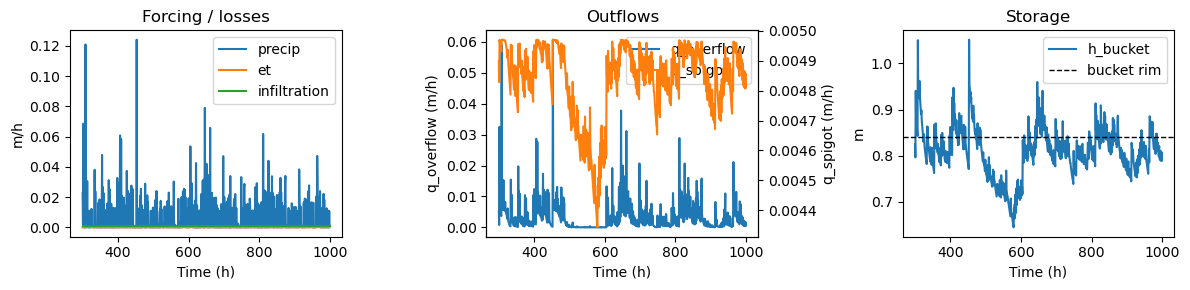

Bucket ID                : 3
Bucket area (m²)         : 1043
Spigot area (m²)         : 8.201e-05
Bucket height (m)        : 0.7201
Spigot height (m)        : 0.02021
K_infiltration (log10)   : -13.25
ET parameter (m/day)     : 0.001388
Soil depth (m)           : 0.7587
Overflow mean (m/h)      : 0.001539
Overflow max (m/h)       : 0.06185

Mass-balance summary (final):
Total precip (m)         : 3.079
Total ET (m)             : 0.05796
Total infiltration (m)   : 0.6925
Total runoff (m)         : 2.43
Final storage (m)        : 0.701
Mass out + stored (m)    : 3.88
Residual fraction        : -26.03%


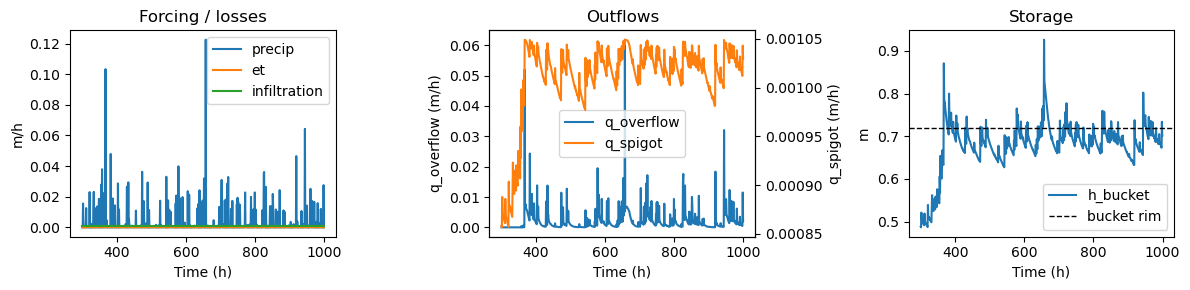

Bucket ID                : 4
Bucket area (m²)         : 834.6
Spigot area (m²)         : 0.0001073
Bucket height (m)        : 1.148
Spigot height (m)        : 0.01556
K_infiltration (log10)   : -13.14
ET parameter (m/day)     : 0.001891
Soil depth (m)           : 0.7191
Overflow mean (m/h)      : 0.001666
Overflow max (m/h)       : 0.04311

Mass-balance summary (final):
Total precip (m)         : 4.437
Total ET (m)             : 0.07896
Total infiltration (m)   : 0.6925
Total runoff (m)         : 3.511
Final storage (m)        : 1.101
Mass out + stored (m)    : 5.268
Residual fraction        : -18.71%


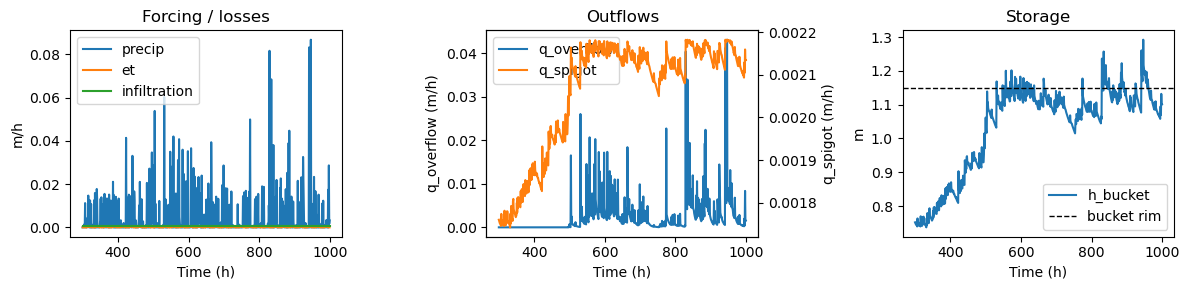

Bucket ID                : 5
Bucket area (m²)         : 678.9
Spigot area (m²)         : 0.0005514
Bucket height (m)        : 1.008
Spigot height (m)        : 0.01991
K_infiltration (log10)   : -14.6
ET parameter (m/day)     : 0.00166
Soil depth (m)           : 0.6565
Overflow mean (m/h)      : 3.372e-19
Overflow max (m/h)       : 9.088e-17

Mass-balance summary (final):
Total precip (m)         : 3.57
Total ET (m)             : 0.06933
Total infiltration (m)   : 0.6925
Total runoff (m)         : 3.149
Final storage (m)        : 0.02009
Mass out + stored (m)    : 3.576
Residual fraction        : -0.17%


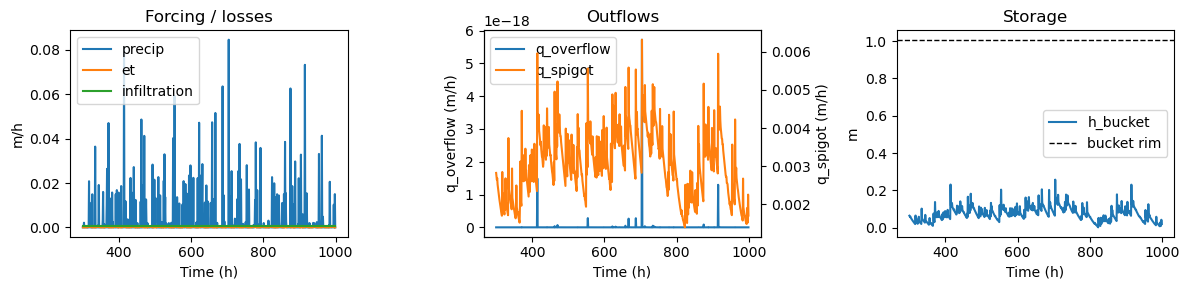

Bucket ID                : 6
Bucket area (m²)         : 688.2
Spigot area (m²)         : 0.0009495
Bucket height (m)        : 1.217
Spigot height (m)        : 0.05054
K_infiltration (log10)   : -11.82
ET parameter (m/day)     : 0.0002955
Soil depth (m)           : 0.6695
Overflow mean (m/h)      : 5.391e-10
Overflow max (m/h)       : 2.894e-07

Mass-balance summary (final):
Total precip (m)         : 2.774
Total ET (m)             : 0.01234
Total infiltration (m)   : 0.6925
Total runoff (m)         : 3.045
Final storage (m)        : -0.006935
Mass out + stored (m)    : 2.768
Residual fraction        : 0.24%


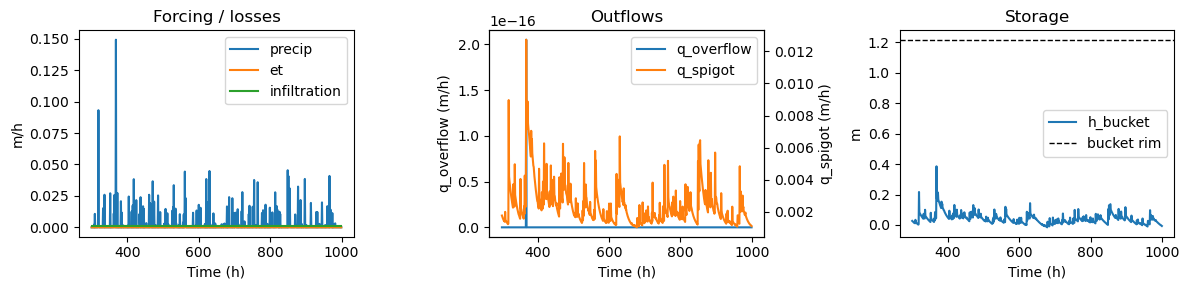

Bucket ID                : 7
Bucket area (m²)         : 1425
Spigot area (m²)         : 9.955e-05
Bucket height (m)        : 0.7256
Spigot height (m)        : 0.03498
K_infiltration (log10)   : -14.45
ET parameter (m/day)     : 0.0009221
Soil depth (m)           : 0.3451
Overflow mean (m/h)      : 0.003701
Overflow max (m/h)       : 0.04441

Mass-balance summary (final):
Total precip (m)         : 4.286
Total ET (m)             : 0.03851
Total infiltration (m)   : 0.6925
Total runoff (m)         : 4.588
Final storage (m)        : 0.6913
Mass out + stored (m)    : 5.606
Residual fraction        : -30.79%


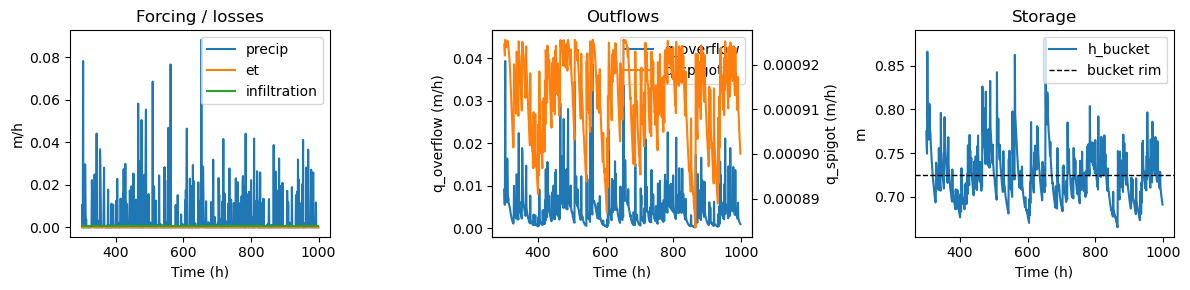

Bucket ID                : 8
Bucket area (m²)         : 642.5
Spigot area (m²)         : 0.0007191
Bucket height (m)        : 1.091
Spigot height (m)        : 0.03984
K_infiltration (log10)   : -15.26
ET parameter (m/day)     : 0.002268
Soil depth (m)           : 0.6307
Overflow mean (m/h)      : 4.308e-15
Overflow max (m/h)       : 4.272e-12

Mass-balance summary (final):
Total precip (m)         : 6.721
Total ET (m)             : 0.09472
Total infiltration (m)   : 0.6925
Total runoff (m)         : 6.311
Final storage (m)        : 0.1014
Mass out + stored (m)    : 6.744
Residual fraction        : -0.34%


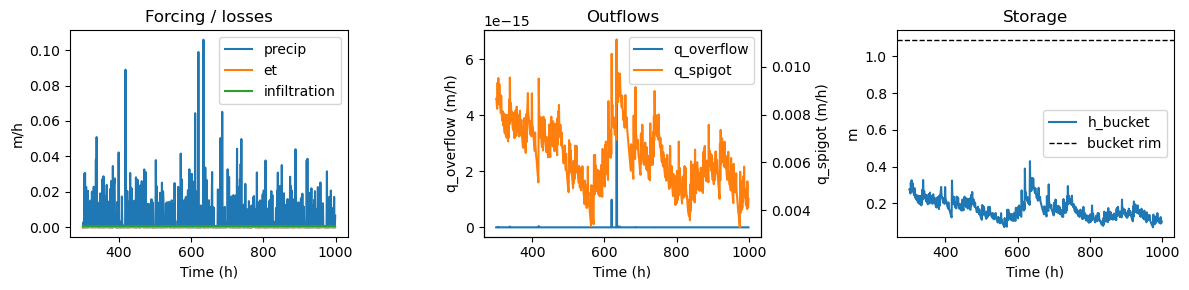

Bucket ID                : 9
Bucket area (m²)         : 1975
Spigot area (m²)         : 0.0002074
Bucket height (m)        : 0.5682
Spigot height (m)        : 0.01465
K_infiltration (log10)   : -12.81
ET parameter (m/day)     : 0.001956
Soil depth (m)           : 0.7067
Overflow mean (m/h)      : 0.003353
Overflow max (m/h)       : 0.06731

Mass-balance summary (final):
Total precip (m)         : 4.209
Total ET (m)             : 0.08169
Total infiltration (m)   : 0.6925
Total runoff (m)         : 4.53
Final storage (m)        : 0.565
Mass out + stored (m)    : 5.671
Residual fraction        : -34.75%


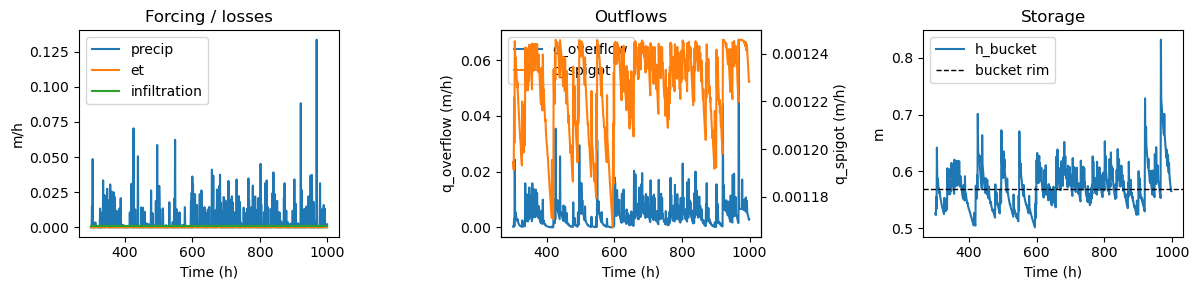

In [18]:
for i in range(min(n_buckets, 10)):
    viz_simulation(i, start=300, n=900)